<div style="text-align: center; padding: 20px 0;">
    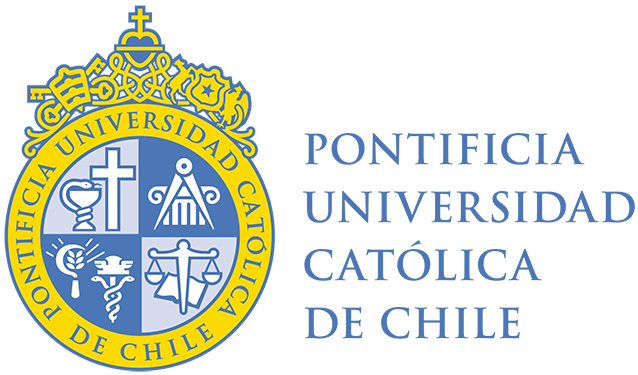
    <h1 style="margin-top: 15px; color: #2c3e50;">IMT-3860: Introducción a Data Science</h1>
    <h2 style="color: #34495e;">Taller 1 — Vulnerabilidad Sociodemográfica y Desigualdad Educativa en la RM</h2>
    <hr style="width: 60%; border: 1px solid #bdc3c7;"/>
    <table style="margin: 15px auto; font-size: 14px; border-collapse: collapse;">
        <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Integrantes:</td>
            <td style="padding: 4px 15px; text-align: left;">Armando Arredondo, Bastián Hernández, Eduardo Albornoz</td></tr>
        <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Profesor:</td>
            <td style="padding: 4px 15px; text-align: left;">Alejandro Cataldo Cornejo</td></tr>
        <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Fecha:</td>
            <td style="padding: 4px 15px; text-align: left;">Abril 2026</td></tr>
        <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Institución:</td>
            <td style="padding: 4px 15px; text-align: left;">Pontificia Universidad Católica de Chile</td></tr>
    </table>
</div>

## 1. Pregunta de Investigación

> **¿Cuáles son las zonas de mayor vulnerabilidad sociodemográfica en la Región Metropolitana, y es la desigualdad educativa un predictor significativo de esa vulnerabilidad?**

### 1.1 Contexto y Motivación

La seguridad pública es la principal contingencia en Chile en 2026. El crimen organizado ha expandido su presencia territorial en Santiago, y la literatura criminológica muestra que el reclutamiento ocurre con mayor intensidad en zonas con alta concentración de jóvenes, baja escolaridad, hacinamiento y migración.

Al mismo tiempo, la **desigualdad educativa** entre comunas de la RM es uno de los indicadores más robustos de desarrollo humano y movilidad social. Chile ha experimentado un crecimiento sostenido de la inmigración, concentrándose fuertemente en la RM, lo que plantea preguntas sobre cómo la distribución espacial de la población migrante se relaciona con los niveles educativos.

Este análisis **fusiona ambas perspectivas**: construimos un índice de vulnerabilidad multivariable y luego evaluamos estadísticamente si la desigualdad educativa es su principal motor.

### 1.2 Relevancia

- **Planificación de políticas públicas**: focalización de recursos en zonas vulnerables.
- **Análisis geoespacial**: uso de datos censales con dimensión territorial (Clase 1 — John Snow, relaciones espaciales).
- **Métodos estadísticos**: EDA, correlación de Pearson, bootstrapping, testeo de hipótesis (Clase 2).
- **Integración de herramientas**: pandas, geopandas, matplotlib, sklearn — todo el stack del curso.

## 2. Configuración del Entorno

In [27]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr
from great_tables import GT, loc, style, md

# --- Report-quality style ---
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.15,
              palette='muted', rc={
    'figure.figsize': (14, 7),
    'figure.dpi': 150,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'font.family': 'sans-serif',
})

PALETTE = sns.color_palette('muted')
C_PRIMARY   = PALETTE[0]   # blue
C_SECONDARY = PALETTE[3]   # red/coral
C_ACCENT    = PALETTE[2]   # green
C_HIGHLIGHT = '#e74c3c'

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.4f}'.format)

def gt_table(df, title='', subtitle='', source='Censo 2017 — INE Chile'):
    """Create a publication-quality table using great_tables (like R's gt)."""
    gt = (
        GT(df.reset_index() if df.index.name else df)
        .tab_header(title=md(f'**{title}**'), subtitle=subtitle)
        .tab_source_note(source_note=source)
        .tab_options(
            heading_background_color='#2c3e50',
            heading_title_font_size='16px',
            heading_subtitle_font_size='12px',
            column_labels_background_color='#34495e',
            column_labels_font_weight='bold',
            table_font_size='12px',
            data_row_padding='6px',
            source_notes_font_size='10px',
        )
        .tab_style(
            style=style.text(color='white'),
            locations=loc.header()
        )
        .tab_style(
            style=style.text(color='white'),
            locations=loc.column_labels()
        )
    )
    # Format numeric columns
    num_cols = df.select_dtypes(include='number').columns.tolist()
    if num_cols:
        gt = gt.fmt_number(columns=num_cols, decimals=3, use_seps=True)
    return gt

print('✓ Entorno configurado — great_tables + seaborn activos')

✓ Entorno configurado — great_tables + seaborn activos


## 3. Carga y Exploración de Datos

In [28]:
# Cargar microdatos censales y shapefile de zonas censales
censo = pd.read_csv('censoRM/CensoRM.csv')
zonas_censales = gpd.read_file('Zonas_rm/Zona_censal.shp')

print(f'Registros censales:  {len(censo):>12,}')
print(f'Columnas:            {len(censo.columns):>12}')
print(f'Zonas censales (shp): {len(zonas_censales):>11,}')
print()

gt_table(
    censo.describe().T.round(3),
    title='Resumen Estadístico del Censo RM 2017',
    subtitle='Estadísticas descriptivas de todas las variables numéricas'
)

Registros censales:     7,112,808
Columnas:                      48
Zonas censales (shp):       1,847



GT(_tbl_data=                       count        mean        std         min         25%  \
REGION        7,112,808.0000     13.0000     0.0000     13.0000     13.0000   
PROVINCIA     7,112,808.0000    131.6860     1.3660    131.0000    131.0000   
COMUNA        7,112,808.0000 13,180.7050   131.8390 13,101.0000 13,111.0000   
DC            7,112,808.0000      6.8480     7.5000      1.0000      2.0000   
AREA          7,112,808.0000      1.0370     0.1890      1.0000      1.0000   
ZC_LOC        7,112,808.0000      7.6290    58.5880      1.0000      2.0000   
ID_ZONA_LOC   7,112,808.0000  7,942.2800 4,656.8740      1.0000  3,996.0000   
NVIV          7,112,808.0000    661.4960   471.9130      1.0000    277.0000   
NHOGAR        7,112,808.0000      1.0380     0.3340      1.0000      1.0000   
PERSONAN      7,112,808.0000     10.2390   144.0520      1.0000      1.0000   
P07           7,112,808.0000      4.6050     4.0980      1.0000      1.0000   
P08           7,112,808.0000      1.5130     0.5000      1.0000      1.0000   
P09           7,112,808.0000     35.5700    21.6190      0.0000     19.0000   
P10           7,112,808.0000      2.2230    10.5720      1.0000      1.0000   
P10COMUNA     7,112,808.0000    351.0310 1,740.1660     98.0000     98.0000   
P10PAIS       7,112,808.0000    996.2440    37.2050      2.0000    998.0000   
P11           7,112,808.0000      4.4950    14.2100      1.0000      2.0000   
P11COMUNA     7,112,808.0000  2,138.2330 4,625.0350     98.0000     98.0000   
P11PAIS       7,112,808.0000    986.4380    85.0880      2.0000    998.0000   
P12           7,112,808.0000      3.6440    12.8550      1.0000      1.0000   
P12COMUNA     7,112,808.0000  6,291.8940 6,087.9960     98.0000     98.0000   
P12PAIS       7,112,808.0000    983.4910    95.9240      2.0000    998.0000   
P12A_LLEGADA  7,112,808.0000  9,513.1290 1,907.4650  1,950.0000  9,998.0000   
P12A_TRAMO    7,112,808.0000     91.5580    24.1320      1.0000     98.0000   
P13           7,112,808.0000      3.9580    14.5330      1.0000      1.0000   
P14           7,112,808.0000     10.6800    24.7830      0.0000      2.0000   
P15           7,112,808.0000     13.1320    21.5100      1.0000      5.0000   
P15A          7,112,808.0000      8.1900    24.7360      1.0000      1.0000   
P16           7,112,808.0000      4.6770    16.1880      1.0000      2.0000   
P16A          7,112,808.0000     88.6220    28.6010      1.0000     98.0000   
P16A_OTRO     7,112,808.0000     97.8810     3.2680      3.0000     98.0000   
P17           7,112,808.0000     23.0300    38.8810      1.0000      1.0000   
P19           7,112,808.0000     59.5540    47.1400      0.0000      2.0000   
P20           7,112,808.0000     70.1770    43.4530      0.0000      4.0000   
P21M          7,112,808.0000     71.6700    41.4900      1.0000     11.0000   
P21A          7,112,808.0000  7,693.5730 3,623.2170  1,927.0000  2,014.0000   
P10PAIS_GRUPO 7,112,808.0000    995.7600    44.5280      2.0000    998.0000   
P11PAIS_GRUPO 7,112,808.0000    969.5540   145.4800      2.0000    998.0000   
P12PAIS_GRUPO 7,112,808.0000    954.6900   175.3000      2.0000    998.0000   
ESCOLARIDAD   7,112,808.0000     12.9670    16.9860      0.0000      7.0000   
P16A_GRUPO    7,112,808.0000     88.6180    28.6130      1.0000     98.0000   
REGION_15R    7,112,808.0000     13.0000     0.0000     13.0000     13.0000   
PROVINCIA_15R 7,112,808.0000    131.6860     1.3660    131.0000    131.0000   
COMUNA_15R    7,112,808.0000 13,180.7050   131.8390 13,101.0000 13,111.0000   
P10COMUNA_15R 7,112,808.0000    348.6190 1,723.5520     98.0000     98.0000   
P11COMUNA_15R 7,112,808.0000  2,125.5980 4,597.2330     98.0000     98.0000   
P12COMUNA_15R 7,112,808.0000  6,185.9140 5,981.8360     98.0000     98.0000   

                      50%         75%         max  
REGION            13.0000     13.0000     13.0000  
PROVINCIA        131.0000    132.0000    136.0000  
COMUNA        13,121.0000 13,201.0000 

### 3.1 Generación de ID único por zona censal

Para vincular los microdatos con el shapefile, construimos un identificador único por zona concatenando los códigos de comuna, distrito censal y zona censal.

In [29]:
# ID único para microdatos
censo['ID_ZONA_U'] = (
    censo['COMUNA'].astype(str)
    + censo['DC'].astype(str)
    + censo['ZC_LOC'].astype(str)
)

# ID único para shapefile
zonas_censales['ID_ZONA_U'] = (
    zonas_censales['COMUNA'].astype(str)
    + zonas_censales['COD_DIS'].astype(int).astype(str)
    + zonas_censales['COD_ZONA'].astype(int).astype(str)
)

print(f'Zonas únicas en censo: {censo["ID_ZONA_U"].nunique()}')
print(f'Zonas únicas en shapefile: {zonas_censales["ID_ZONA_U"].nunique()}')

Zonas únicas en censo: 2356
Zonas únicas en shapefile: 1843


## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Distribución etaria y educativa

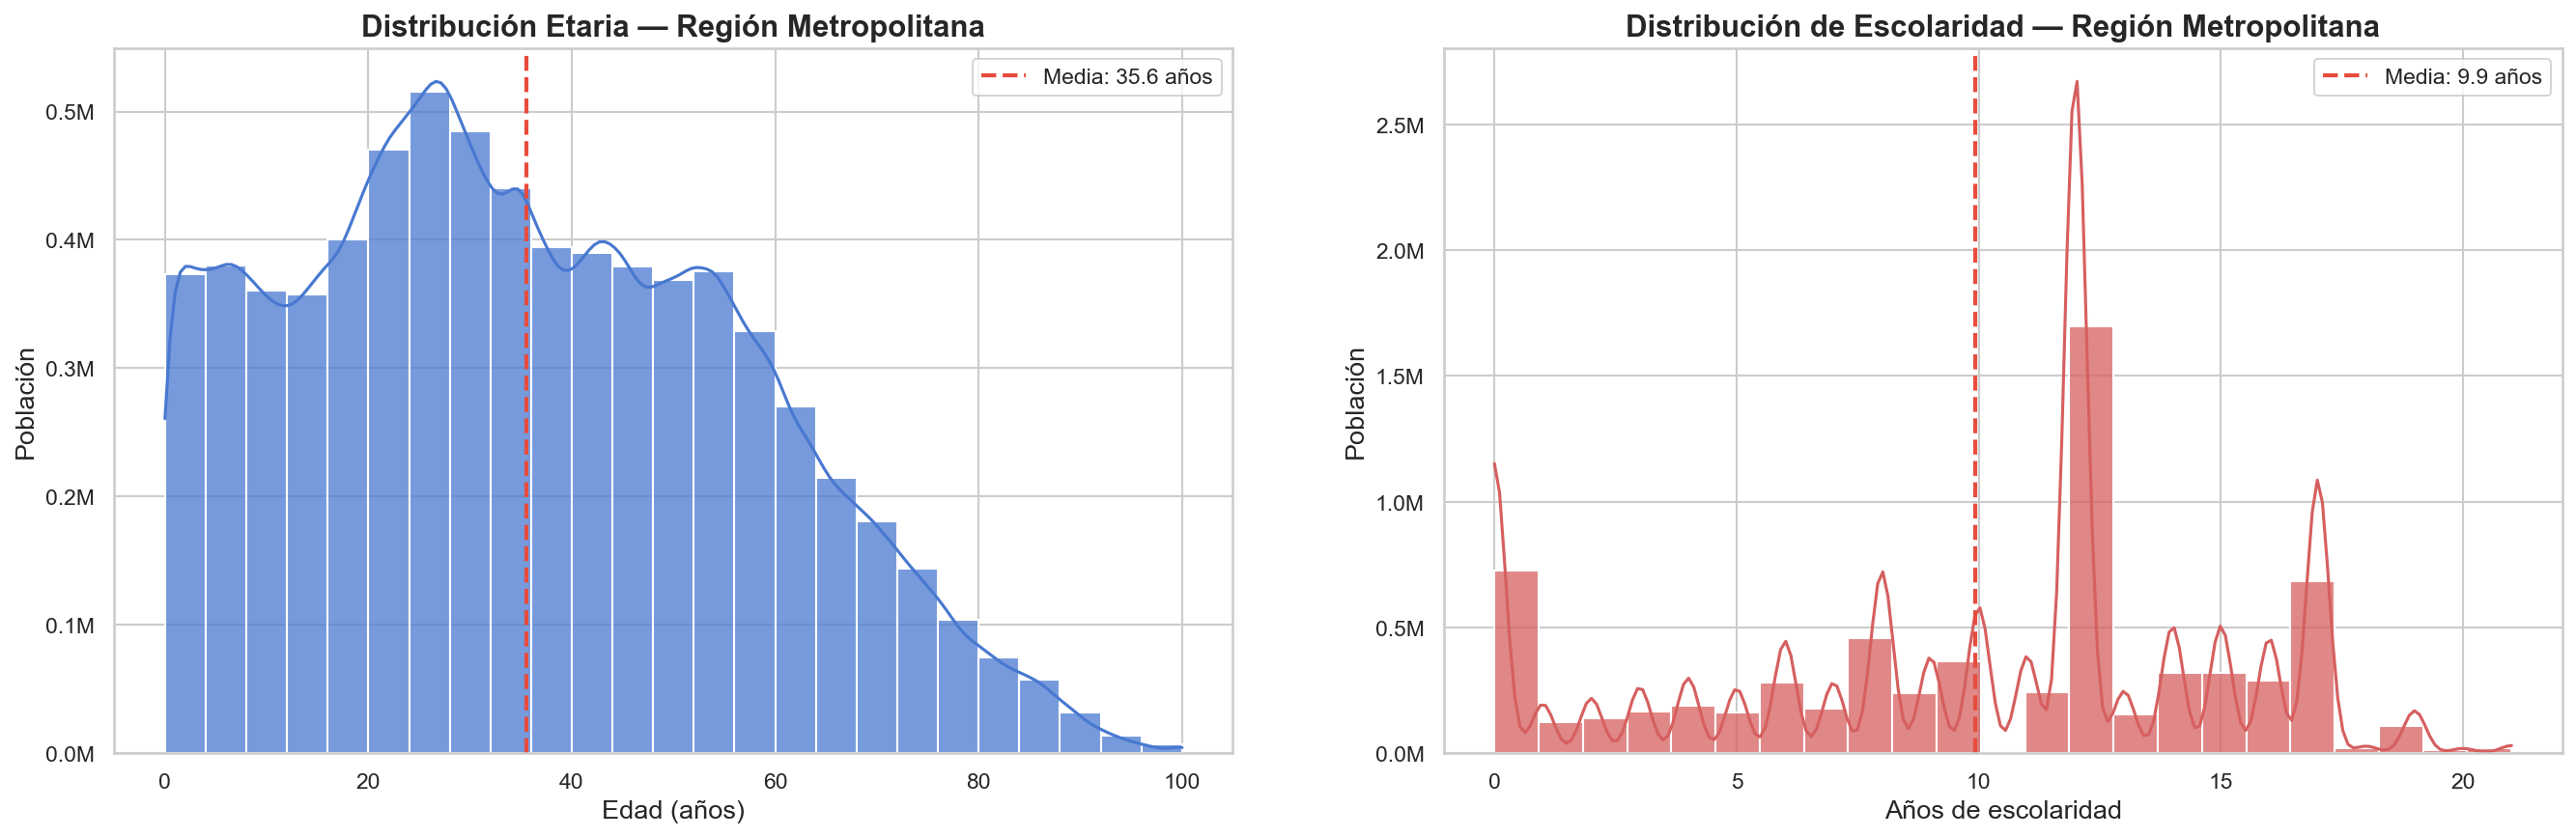


Escolaridad — Media: 9.93 | Desv. Std: 5.35 | Máx: 21


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Distribución etaria ---
sns.histplot(censo['P09'], bins=25, kde=True, color=C_PRIMARY, edgecolor='white',
             alpha=0.75, ax=axes[0], stat='count')
mean_age = censo['P09'].mean()
axes[0].axvline(mean_age, color=C_HIGHLIGHT, linewidth=2, linestyle='--',
                label=f'Media: {mean_age:.1f} años')
axes[0].set_title('Distribución Etaria — Región Metropolitana')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Población')
axes[0].legend(frameon=True, facecolor='white', edgecolor='#ccc')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# --- Distribución de escolaridad ---
esc_valid = censo[censo['ESCOLARIDAD'] != 99]['ESCOLARIDAD']
sns.histplot(esc_valid, bins=23, kde=True, color=C_SECONDARY, edgecolor='white',
             alpha=0.75, ax=axes[1], stat='count')
mean_esc = esc_valid.mean()
axes[1].axvline(mean_esc, color=C_HIGHLIGHT, linewidth=2, linestyle='--',
                label=f'Media: {mean_esc:.1f} años')
axes[1].set_title('Distribución de Escolaridad — Región Metropolitana')
axes[1].set_xlabel('Años de escolaridad')
axes[1].set_ylabel('Población')
axes[1].legend(frameon=True, facecolor='white', edgecolor='#ccc')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout(w_pad=4)
plt.savefig('fig_eda_distribuciones.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print(f'\nEscolaridad — Media: {mean_esc:.2f} | Desv. Std: {esc_valid.std():.2f} | Máx: {esc_valid.max()}')

### 4.2 Escolaridad por comuna (boxplot)

C:\Users\PC BEAR\AppData\Local\Temp\ipykernel_42344\1513573043.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=censo_top, x='COMUNA_NOMBRE', y='ESCOLARIDAD', order=order,


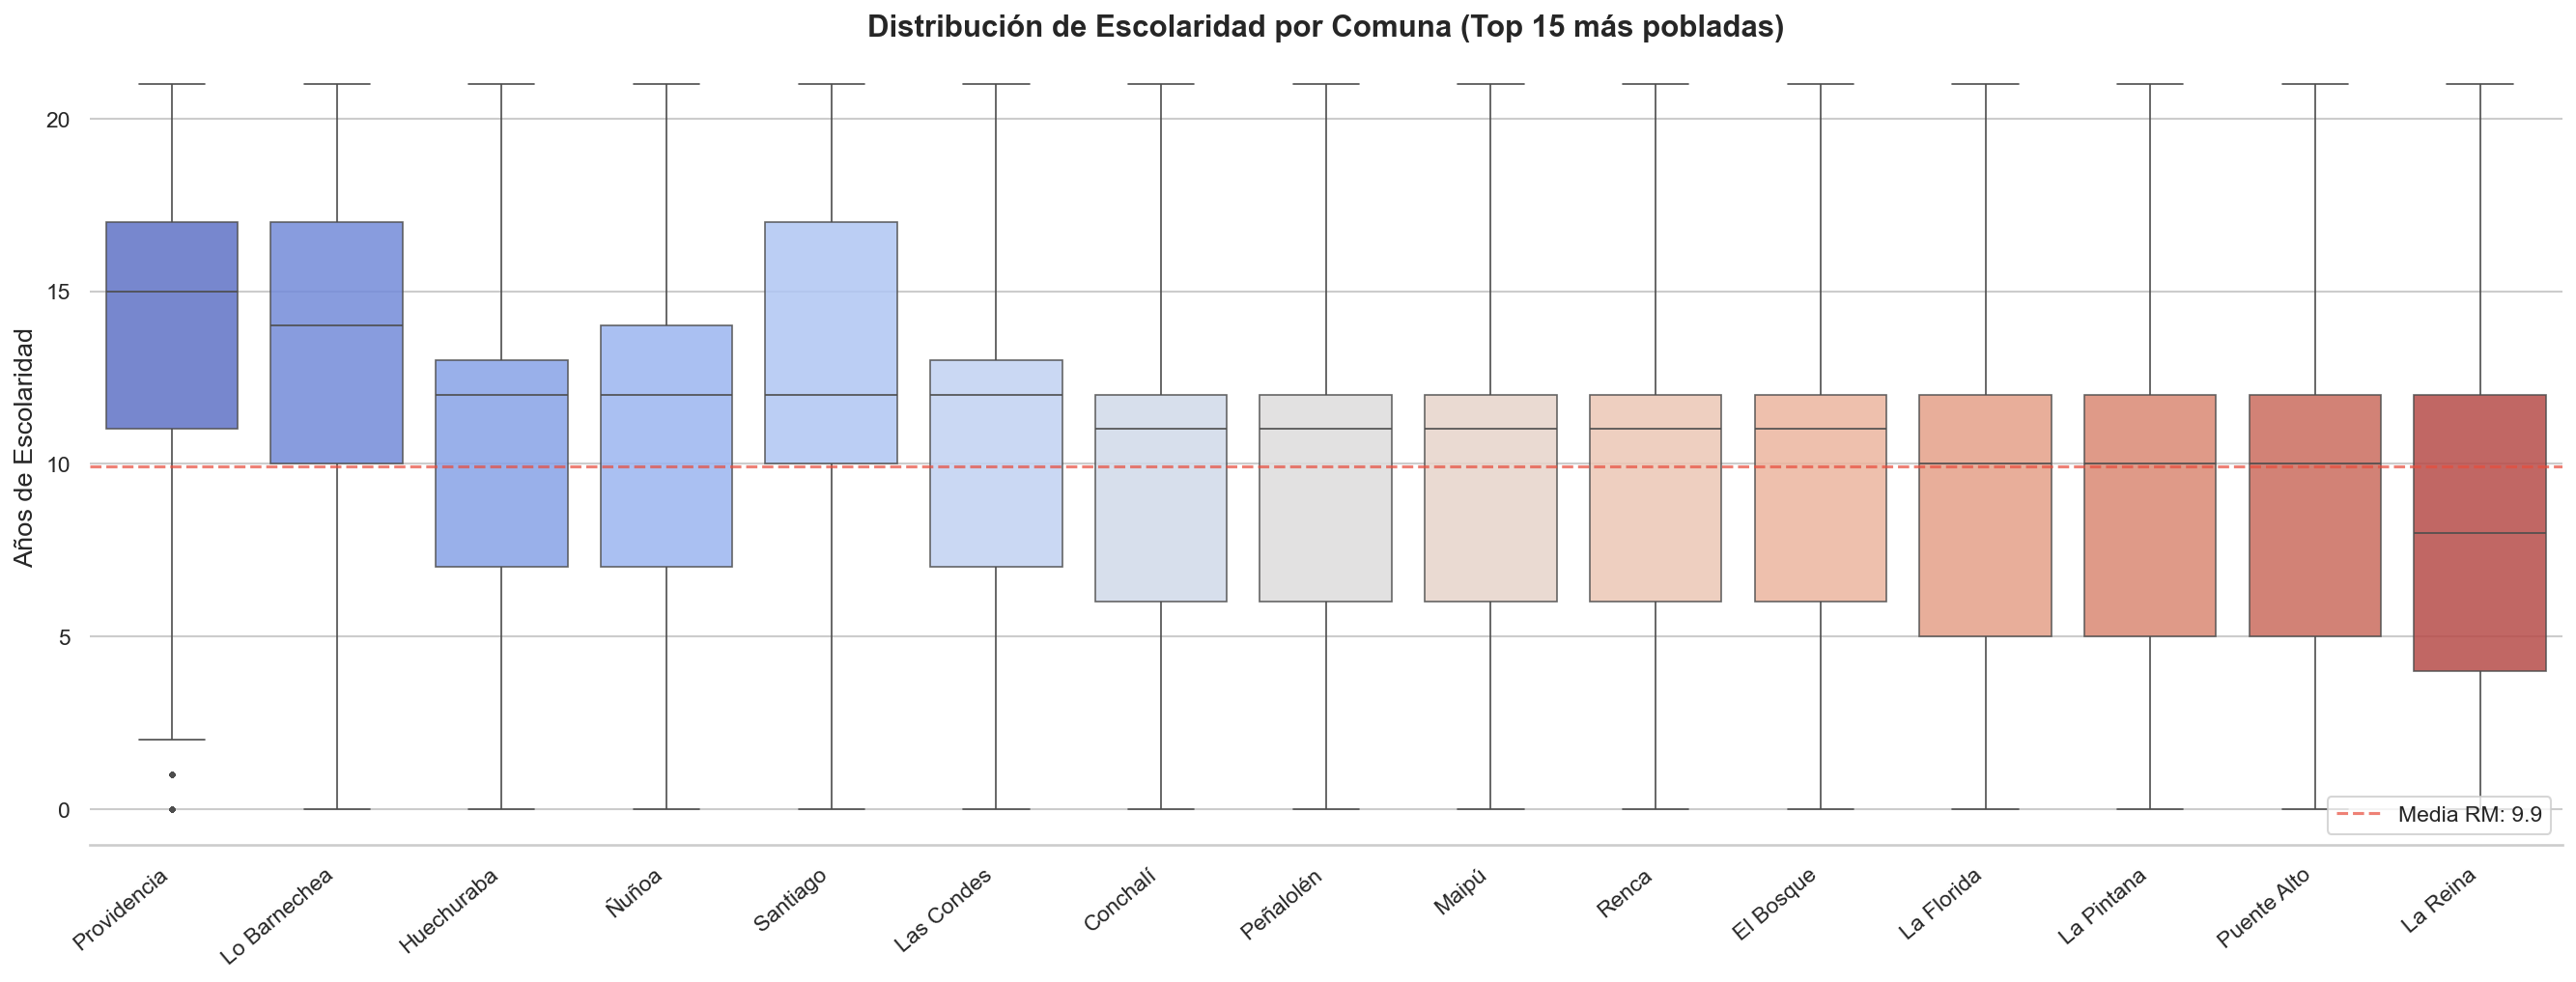

In [31]:
# Top 15 comunas más pobladas
top_comunas = censo['COMUNA'].value_counts().head(15).index
censo_top = censo[(censo['COMUNA'].isin(top_comunas)) & (censo['ESCOLARIDAD'] != 99)]

# Nombre mapping para comunas frecuentes (códigos -> nombres)
comuna_names = {
    13101: 'Santiago', 13401: 'Puente Alto', 13201: 'Maipú',
    13110: 'Ñuñoa', 13114: 'Providencia', 13119: 'Las Condes',
    13105: 'La Florida', 13122: 'Peñalolén', 13131: 'San Bernardo',
    13132: 'Pudahuel', 13106: 'Huechuraba', 13128: 'La Pintana',
    13126: 'Quilicura', 13130: 'San Miguel', 13112: 'La Reina',
    13120: 'Lo Barnechea', 13104: 'Estación Central', 13102: 'Cerrillos',
    13111: 'La Granja', 13115: 'Recoleta', 13118: 'Lo Espejo',
    13103: 'Cerro Navia', 13109: 'Macul', 13108: 'Lo Prado',
    13121: 'Pedro Aguirre Cerda', 13125: 'El Bosque', 13124: 'Conchalí',
    13127: 'Renca', 13123: 'Independencia', 13107: 'La Cisterna',
    13116: 'San Joaquín', 13129: 'Vitacura', 13113: 'San Ramón',
    13117: 'Lo Espejo',
}
censo_top = censo_top.copy()
censo_top['COMUNA_NOMBRE'] = censo_top['COMUNA'].map(comuna_names).fillna(censo_top['COMUNA'].astype(str))

fig, ax = plt.subplots(figsize=(18, 7))
order = (censo_top.groupby('COMUNA_NOMBRE')['ESCOLARIDAD']
         .median().sort_values(ascending=False).index)

sns.boxplot(data=censo_top, x='COMUNA_NOMBRE', y='ESCOLARIDAD', order=order,
            palette='coolwarm', linewidth=0.8, fliersize=1.5, ax=ax,
            boxprops=dict(alpha=0.85))
ax.set_title('Distribución de Escolaridad por Comuna (Top 15 más pobladas)')
ax.set_xlabel('')
ax.set_ylabel('Años de Escolaridad')
ax.tick_params(axis='x', rotation=40)
for label in ax.get_xticklabels():
    label.set_ha('right')

# Línea de referencia con la media general
ax.axhline(esc_valid.mean(), color=C_HIGHLIGHT, linestyle='--', alpha=0.7,
           label=f'Media RM: {esc_valid.mean():.1f}')
ax.legend(loc='lower right', frameon=True, facecolor='white')

sns.despine(left=True)
plt.tight_layout()
plt.savefig('fig_boxplot_comunas.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 5. Construcción del Índice de Vulnerabilidad

Construimos un índice compuesto de vulnerabilidad sociodemográfica por zona censal, basado en 5 indicadores normalizados:

| Variable | Indicador | Lógica |
|---|---|---|
| `P09` (edad) | % población 15–29 años | Mayor proporción joven → mayor vulnerabilidad |
| `P08` (sexo) | % hombres jóvenes (15–29) | Mayor proporción → mayor vulnerabilidad |
| `ESCOLARIDAD` | Escolaridad promedio | **Menor** escolaridad → mayor vulnerabilidad (se invierte) |
| `P12PAIS_GRUPO` | % población extranjera | Mayor proporción → mayor vulnerabilidad |
| `PERSONAN` | Personas promedio por hogar | Mayor hacinamiento → mayor vulnerabilidad |

In [32]:
# --- Indicador 1: % población joven (15-29) ---
censo['JOVEN'] = ((censo['P09'] >= 15) & (censo['P09'] <= 29)).astype(int)
joven_zona = censo.groupby('ID_ZONA_U')['JOVEN'].mean().rename('PCT_JOVEN')

# --- Indicador 2: % hombres jóvenes (15-29) ---
censo['HOMBRE_JOVEN'] = (
    (censo['P09'] >= 15) & (censo['P09'] <= 29) & (censo['P08'] == 1)
).astype(int)
hombre_joven_zona = censo.groupby('ID_ZONA_U')['HOMBRE_JOVEN'].mean().rename('PCT_HOMBRE_JOVEN')

# --- Indicador 3: escolaridad promedio (excluir código 99) ---
escolaridad_zona = (
    censo[censo['ESCOLARIDAD'] != 99]
    .groupby('ID_ZONA_U')['ESCOLARIDAD']
    .mean()
    .rename('ESCOLARIDAD_PROM')
)

# --- Indicador 4: % población extranjera ---
censo['EXTRANJERO'] = (censo['P12PAIS_GRUPO'] != 998).astype(int)
extran_zona = censo.groupby('ID_ZONA_U')['EXTRANJERO'].mean().rename('PCT_EXTRAN')

# --- Indicador 5: hacinamiento (personas por hogar) ---
hacin_zona = censo.groupby('ID_ZONA_U')['PERSONAN'].mean().rename('HACIN_PROM')

# Unir indicadores
indicadores = pd.concat(
    [joven_zona, hombre_joven_zona, escolaridad_zona, extran_zona, hacin_zona],
    axis=1
).dropna()

print(f'✓ Zonas con datos completos: {len(indicadores):,}')
print()
gt_table(
    indicadores.describe().T.round(4),
    title='Estadísticas de los 5 Indicadores por Zona Censal',
    subtitle='Valores antes de la normalización MinMaxScaler'
)

✓ Zonas con datos completos: 2,356



GT(_tbl_data=                      count   mean     std    min    25%    50%     75%  \
PCT_JOVEN        2,356.0000 0.2370  0.0482 0.0000 0.2145 0.2348  0.2549   
PCT_HOMBRE_JOVEN 2,356.0000 0.1222  0.0353 0.0000 0.1087 0.1201  0.1316   
ESCOLARIDAD_PROM 2,356.0000 9.8408  1.8055 2.1712 8.4604 9.4716 10.8463   
PCT_EXTRAN       2,356.0000 0.0871  0.0884 0.0000 0.0375 0.0583  0.0966   
HACIN_PROM       2,356.0000 6.7145 76.5103 1.3000 2.4634 2.6004  2.7519   

                        max  
PCT_JOVEN            0.8098  
PCT_HOMBRE_JOVEN     0.7669  
ESCOLARIDAD_PROM    15.5161  
PCT_EXTRAN           0.7568  
HACIN_PROM       2,806.0732  , _body=<great_tables._gt_data.Body object at 0x000001B3EAAC9460>, _boxhead=Boxhead([ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='count', column_align='right', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='min', type=<ColInfoTypeEnum.default: 1>, column_label='min', column_align='right', column_width=None), ColInfo(var='25%', type=<ColInfoTypeEnum.default: 1>, column_label='25%', column_align='right', column_width=None), ColInfo(var='50%', type=<ColInfoTypeEnum.default: 1>, column_label='50%', column_align='right', column_width=None), ColInfo(var='75%', type=<ColInfoTypeEnum.default: 1>, column_label='75%', column_align='right', column_width=None), ColInfo(var='max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001B567A42AB0>, _spanners=Spanners([]), _heading=Heading(title=Md(text='**Estadísticas de los 5 Indicadores por Zona Censal**'), subtitle='Valores antes de la normalización MinMaxScaler', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001B3EAAC9190>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001B567A404D0>, _source_notes=['Censo 2017 — INE Chile'], _footnotes=[], _styles=[StyleInfo(locname=LocHeader(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color='white', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='count', rownum=None, colnum=None, styles=[CellStyleText(color='white', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='mean', rownum=None, colnum=None, styles=[CellStyleText(color='white', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='std', rownum=None, colnum=None, styles=[CellStyleText(color='white', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='min', rownum=None, colnum=None, styles=[CellStyleText(color='white', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='25%', rownum=None, colnum=None, styles=[CellStyleText(color='white', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='50%', rownum=None, colnum=None, styles=[CellStyleText(color='white', font=None, size=None, align=None, v

### 5.1 Normalización y cálculo del índice

In [33]:
scaler = MinMaxScaler()
ind_norm = indicadores.copy()

# Normalizar 0-1
ind_norm[['PCT_JOVEN', 'PCT_HOMBRE_JOVEN', 'PCT_EXTRAN', 'HACIN_PROM']] = scaler.fit_transform(
    indicadores[['PCT_JOVEN', 'PCT_HOMBRE_JOVEN', 'PCT_EXTRAN', 'HACIN_PROM']]
)

# Escolaridad invertida: menor escolaridad = mayor vulnerabilidad
ind_norm['ESCOLARIDAD_INV'] = 1 - scaler.fit_transform(indicadores[['ESCOLARIDAD_PROM']])

# Índice compuesto: promedio de los 5 indicadores normalizados
ind_norm['INDICE_VULNERABILIDAD'] = ind_norm[
    ['PCT_JOVEN', 'PCT_HOMBRE_JOVEN', 'PCT_EXTRAN', 'HACIN_PROM', 'ESCOLARIDAD_INV']
].mean(axis=1)

top10 = ind_norm[['INDICE_VULNERABILIDAD']].sort_values('INDICE_VULNERABILIDAD', ascending=False).head(10)
top10_display = top10.reset_index()
top10_display.index = range(1, 11)
top10_display.index.name = 'Ranking'

(
    GT(top10_display.reset_index())
    .tab_header(title=md('**Top 10 Zonas Censales Más Vulnerables**'), subtitle='Índice compuesto normalizado (0–1)')
    .tab_source_note(source_note='Censo 2017 — INE Chile')
    .cols_label(Ranking='#', ID_ZONA_U='Zona Censal', INDICE_VULNERABILIDAD='Índice')
    .fmt_number(columns='INDICE_VULNERABILIDAD', decimals=4)
    .data_color(columns='INDICE_VULNERABILIDAD', palette='Reds')
    .tab_options(
        heading_background_color='#c0392b',
        heading_title_font_size='16px',
        column_labels_background_color='#e74c3c',
        column_labels_font_weight='bold',
        table_font_size='13px',
        data_row_padding='8px',
    )
    .tab_style(style=style.text(color='white'), locations=loc.header())
    .tab_style(style=style.text(color='white'), locations=loc.column_labels())
)

GT(_tbl_data=   Ranking   ID_ZONA_U  INDICE_VULNERABILIDAD
0        1    13302315                 0.5445
1        2     1312825                 0.4874
2        3    13101221                 0.4529
3        4   135022901                 0.4338
4        5  1310699999                 0.3960
5        6     1330141                 0.3946
6        7    13302319                 0.3652
7        8    13101193                 0.3581
8        9     1310872                 0.3545
9       10     1310813                 0.3544, _body=<great_tables._gt_data.Body object at 0x000001B567A416A0>, _boxhead=Boxhead([ColInfo(var='Ranking', type=<ColInfoTypeEnum.default: 1>, column_label='#', column_align='right', column_width=None), ColInfo(var='ID_ZONA_U', type=<ColInfoTypeEnum.default: 1>, column_label='Zona Censal', column_align='right', column_width=None), ColInfo(var='INDICE_VULNERABILIDAD', type=<ColInfoTypeEnum.default: 1>, column_label='Índice', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001B567A3CE60>, _spanners=Spanners([]), _heading=Heading(title=Md(text='**Top 10 Zonas Censales Más Vulnerables**'), subtitle='Índice compuesto normalizado (0–1)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001B567A3F230>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001B567A3FBF0>, _source_notes=['Censo 2017 — INE Chile'], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='INDICE_VULNERABILIDAD', rows=[0], mask=None), grpname=None, colname='INDICE_VULNERABILIDAD', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#67000d')]), StyleInfo(locname=LocBody(columns='INDICE_VULNERABILIDAD', rows=[1], mask=None), grpname=None, colname='INDICE_VULNERABILIDAD', rownum=1, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#da2623')]), StyleInfo(locname=LocBody(columns='INDICE_VULNERABILIDAD', rows=[2], mask=None), grpname=None, colname='INDICE_VULNERABILIDAD', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#f96346')]), StyleInfo(locname=LocBody(columns='INDICE_VULNERABILIDAD', rows=[3], mask=None), grpname=None, colname='INDICE_VULNERABILIDAD', rownum=3, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#fc8464')]), StyleInfo(locname=LocBody(columns='INDICE_VULNERABILIDAD', rows=[4], mask=None), grpname=None, colname='INDICE_VULNERABILIDAD', rownum=4, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#fcc4ad')]), StyleInfo(locname=LocBody(columns='INDICE_VULNERABILIDAD', rows=[5], mask=None), grpname=None, colname='INDICE_VULNERABILIDAD', rownum=5, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#fdc7b0')]), StyleInfo(locname=LocBody(columns='INDICE_VULNERABILIDAD', rows=[6], mask=None), grpname=None, colname='INDICE_VULNERABILIDAD', rownum=6, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#ffece2')]), StyleInfo(lo

## 6. Análisis de Correlación: ¿Qué indicador impulsa más la vulnerabilidad?

Calculamos la correlación de Pearson (ρ) entre cada componente y el índice compuesto para determinar cuál es el principal predictor.

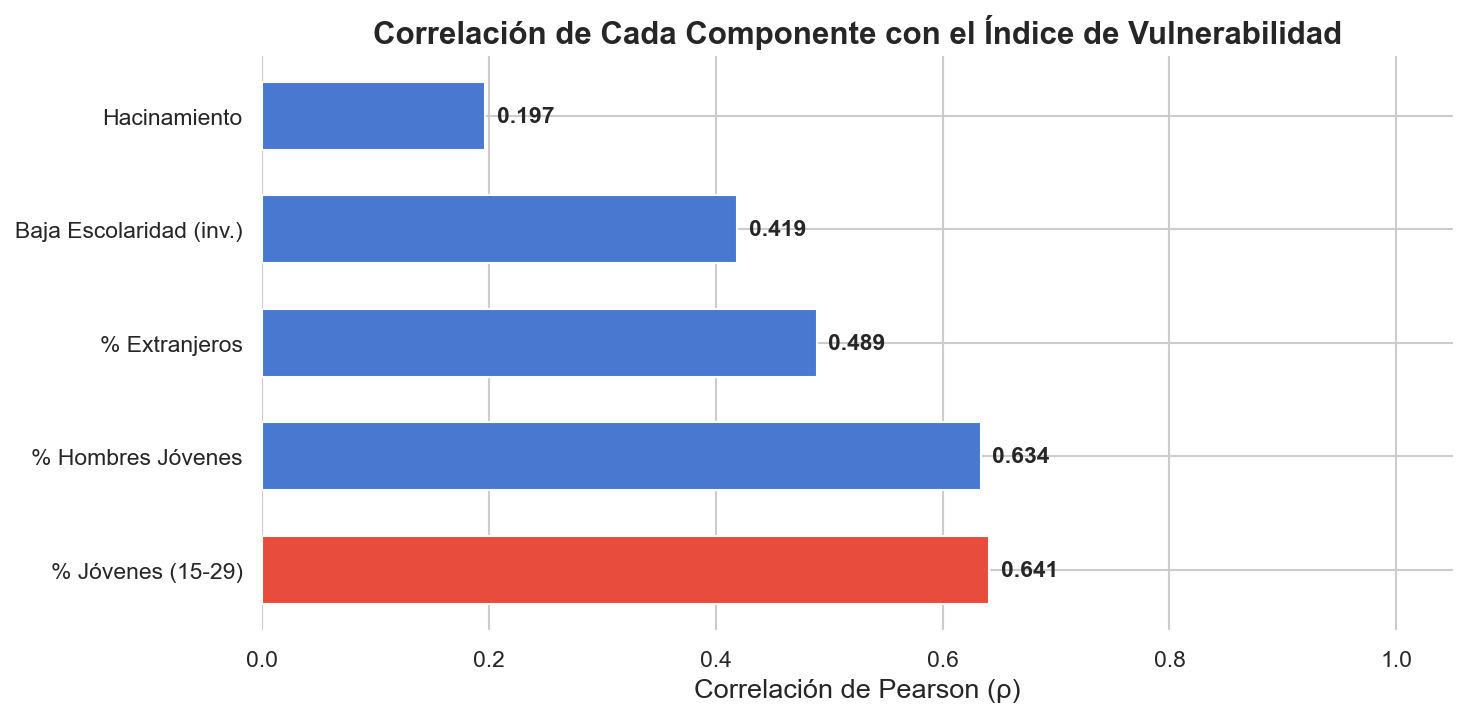

GT(_tbl_data=                 Indicador  Pearson ρ    p-value
0        % Jóvenes (15-29)     0.6411  7.01e-273
1        % Hombres Jóvenes     0.6339  5.88e-265
2            % Extranjeros     0.4887  1.00e-141
3  Baja Escolaridad (inv.)     0.4187  1.12e-100
4             Hacinamiento     0.1967   5.57e-22, _body=<great_tables._gt_data.Body object at 0x000001B567A3E7B0>, _boxhead=Boxhead([ColInfo(var='Indicador', type=<ColInfoTypeEnum.default: 1>, column_label='Indicador', column_align='left', column_width=None), ColInfo(var='Pearson ρ', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson ρ', column_align='right', column_width=None), ColInfo(var='p-value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001B567A32780>, _spanners=Spanners([]), _heading=Heading(title=Md(text='**Correlación de Pearson con el Índice de Vulnerabilidad**'), subtitle='Cada componente vs. el índice compuesto', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001B567A2AA50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001B567A2B080>, _source_notes=['Censo 2017 — INE Chile'], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Pearson ρ', rows=[0], mask=None), grpname=None, colname='Pearson ρ', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#a50026')]), StyleInfo(locname=LocBody(columns='Pearson ρ', rows=[1], mask=None), grpname=None, colname='Pearson ρ', rownum=1, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#ad0826')]), StyleInfo(locname=LocBody(columns='Pearson ρ', rows=[2], mask=None), grpname=None, colname='Pearson ρ', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#fdc373')]), StyleInfo(locname=LocBody(columns='Pearson ρ', rows=[3], mask=None), grpname=None, colname='Pearson ρ', rownum=3, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#ffffbf')]), StyleInfo(locname=LocBody(columns='Pearson ρ', rows=[4], mask=None), grpname=None, colname='Pearson ρ', rownum=4, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#006837')]), StyleInfo(locname=LocHeader(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color='white', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Indicador', rownum=None, colnum=None, styles=[CellStyleText(color='white', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Pearson ρ', rownum=None, colnum=None, styles=[CellStyleText(color='white', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='p-value', rownum=None, colnum=None, styles=[CellStyleText(color='white', font=None, size=None, align=None, v_align=None, style=None, weight=None, s

In [34]:
components = ['PCT_JOVEN', 'PCT_HOMBRE_JOVEN', 'ESCOLARIDAD_INV', 'PCT_EXTRAN', 'HACIN_PROM']
labels = ['% Jóvenes (15-29)', '% Hombres Jóvenes', 'Baja Escolaridad (inv.)', '% Extranjeros', 'Hacinamiento']

correlations = []
for comp, label in zip(components, labels):
    r, p = pearsonr(ind_norm[comp], ind_norm['INDICE_VULNERABILIDAD'])
    correlations.append({'Indicador': label, 'Pearson ρ': r, 'p-value': p})

corr_df = pd.DataFrame(correlations).sort_values('Pearson ρ', ascending=False)

# --- Bar chart de correlaciones ---
fig, ax = plt.subplots(figsize=(10, 5))
colors = [C_HIGHLIGHT if v == corr_df['Pearson ρ'].max() else C_PRIMARY for v in corr_df['Pearson ρ']]
bars = ax.barh(corr_df['Indicador'], corr_df['Pearson ρ'], color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('Correlación de Pearson (ρ)')
ax.set_title('Correlación de Cada Componente con el Índice de Vulnerabilidad')
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, corr_df['Pearson ρ']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('fig_correlaciones.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

# Styled table with great_tables
corr_display = corr_df.copy()
corr_display['p-value'] = corr_display['p-value'].map(lambda x: f'{x:.2e}')
corr_display = corr_display.reset_index(drop=True)

(
    GT(corr_display)
    .tab_header(
        title=md('**Correlación de Pearson con el Índice de Vulnerabilidad**'),
        subtitle='Cada componente vs. el índice compuesto'
    )
    .tab_source_note(source_note='Censo 2017 — INE Chile')
    .fmt_number(columns='Pearson ρ', decimals=4)
    .data_color(columns='Pearson ρ', palette='RdYlGn', reverse=True)
    .tab_options(
        heading_background_color='#2c3e50',
        heading_title_font_size='16px',
        column_labels_background_color='#34495e',
        column_labels_font_weight='bold',
        table_font_size='13px',
        data_row_padding='8px',
    )
    .tab_style(style=style.text(color='white'), locations=loc.header())
    .tab_style(style=style.text(color='white'), locations=loc.column_labels())
)

### 6.1 Scatter: Escolaridad y Migración vs. Vulnerabilidad

C:\Users\PC BEAR\AppData\Local\Temp\ipykernel_42344\1158507681.py:4: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[0].scatter(indicadores['ESCOLARIDAD_PROM'], ind_norm['INDICE_VULNERABILIDAD'],
C:\Users\PC BEAR\AppData\Local\Temp\ipykernel_42344\1158507681.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[1].scatter(indicadores['PCT_EXTRAN'] * 100, ind_norm['INDICE_VULNERABILIDAD'],


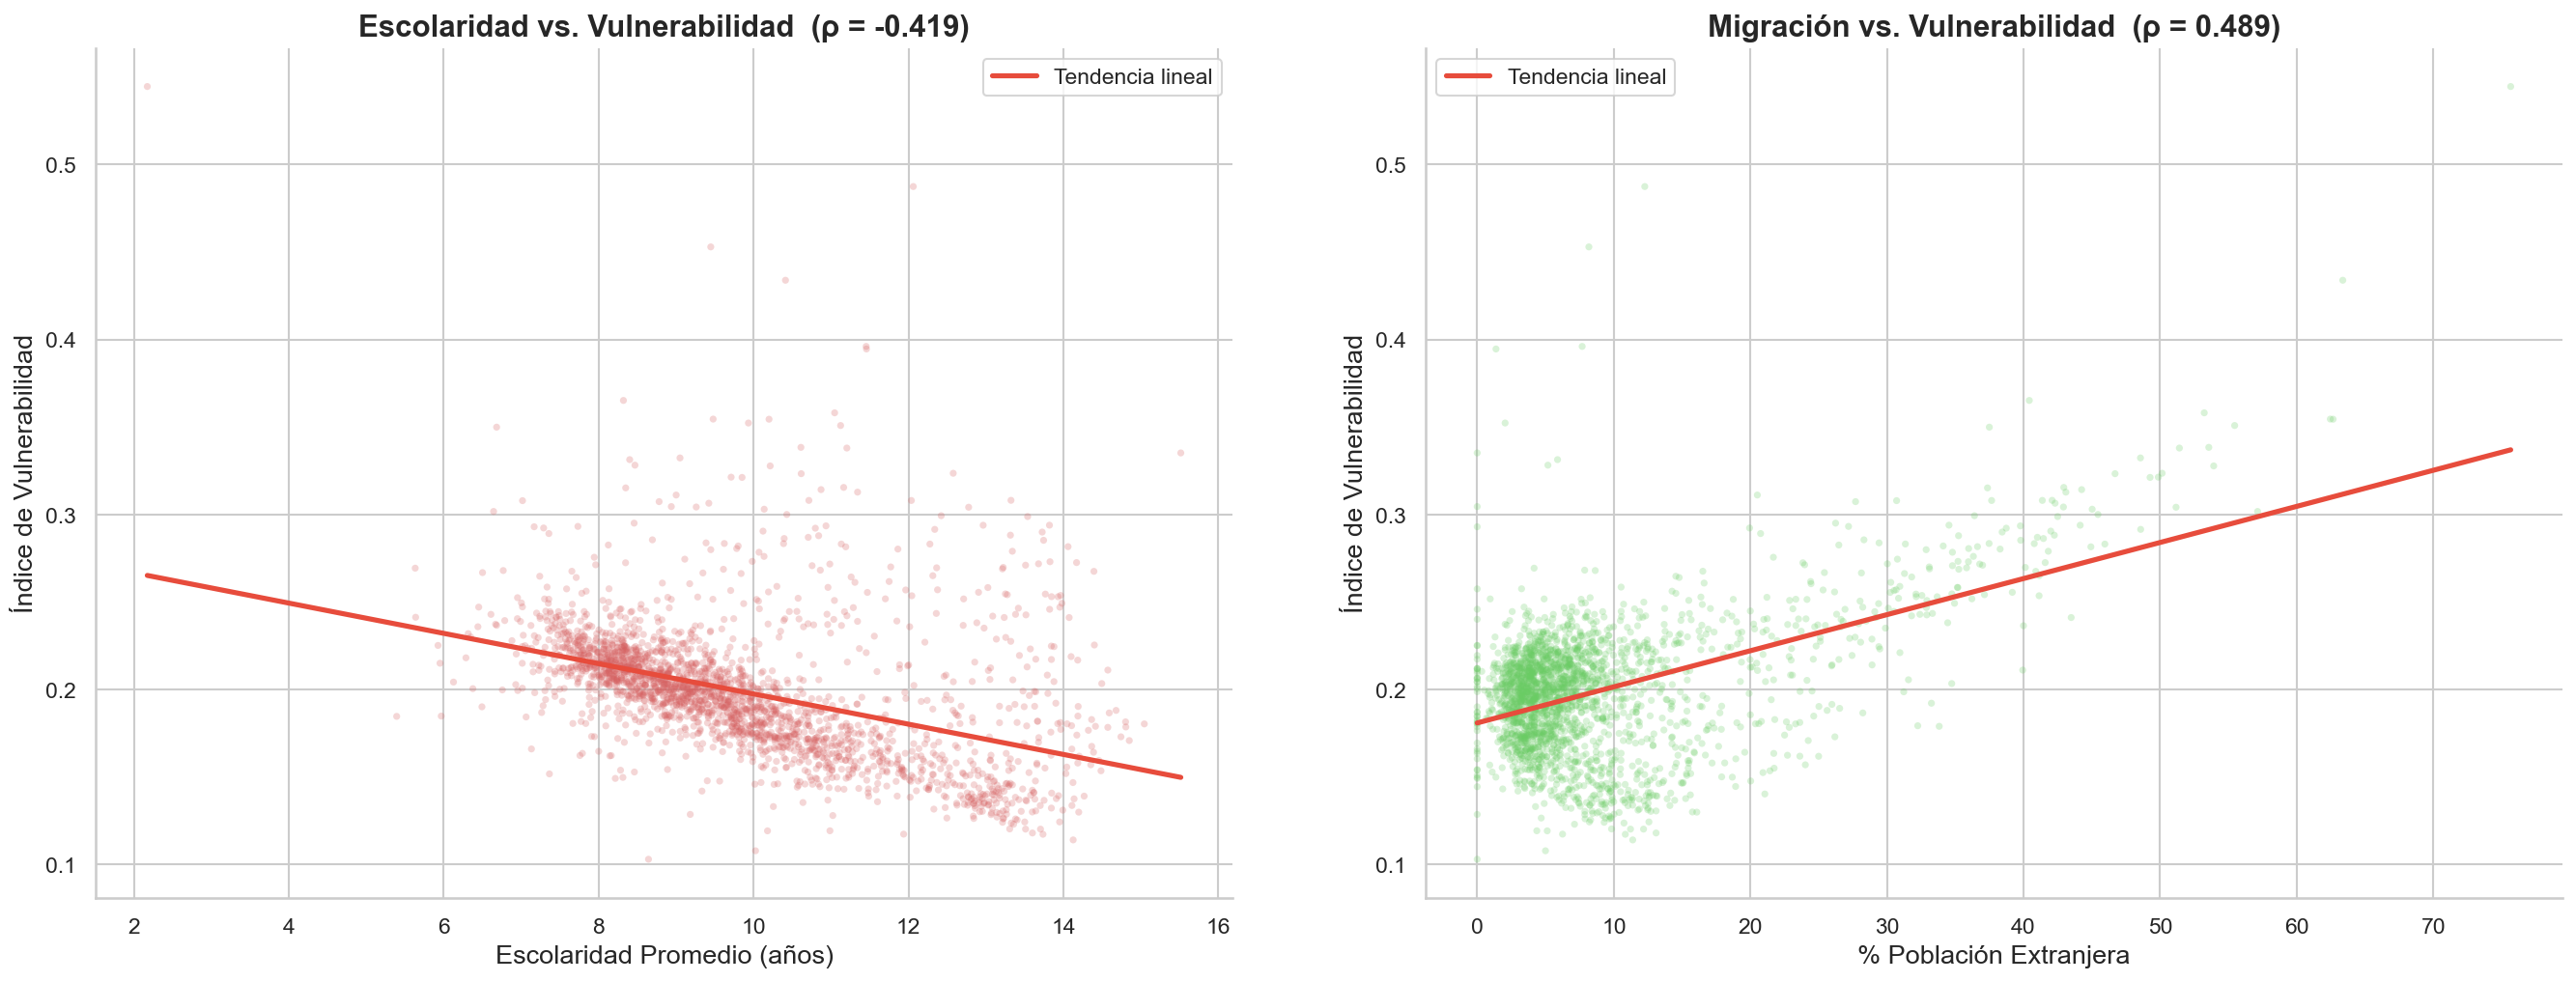

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Scatter: escolaridad vs vulnerabilidad ---
axes[0].scatter(indicadores['ESCOLARIDAD_PROM'], ind_norm['INDICE_VULNERABILIDAD'],
                alpha=0.25, s=12, c=C_SECONDARY, edgecolors='none')
# Trend line
z = np.polyfit(indicadores['ESCOLARIDAD_PROM'], ind_norm['INDICE_VULNERABILIDAD'], 1)
x_line = np.linspace(indicadores['ESCOLARIDAD_PROM'].min(), indicadores['ESCOLARIDAD_PROM'].max(), 100)
axes[0].plot(x_line, np.polyval(z, x_line), color=C_HIGHLIGHT, linewidth=2.5,
             linestyle='-', label=f'Tendencia lineal')
r_esc, _ = pearsonr(indicadores['ESCOLARIDAD_PROM'], ind_norm['INDICE_VULNERABILIDAD'])
axes[0].set_xlabel('Escolaridad Promedio (años)')
axes[0].set_ylabel('Índice de Vulnerabilidad')
axes[0].set_title(f'Escolaridad vs. Vulnerabilidad  (ρ = {r_esc:.3f})')
axes[0].legend(frameon=True, facecolor='white')

# --- Scatter: % extranjeros vs vulnerabilidad ---
axes[1].scatter(indicadores['PCT_EXTRAN'] * 100, ind_norm['INDICE_VULNERABILIDAD'],
                alpha=0.25, s=12, c=C_ACCENT, edgecolors='none')
z2 = np.polyfit(indicadores['PCT_EXTRAN'] * 100, ind_norm['INDICE_VULNERABILIDAD'], 1)
x_line2 = np.linspace(0, indicadores['PCT_EXTRAN'].max() * 100, 100)
axes[1].plot(x_line2, np.polyval(z2, x_line2), color=C_HIGHLIGHT, linewidth=2.5,
             linestyle='-', label='Tendencia lineal')
r_ext, _ = pearsonr(indicadores['PCT_EXTRAN'], ind_norm['INDICE_VULNERABILIDAD'])
axes[1].set_xlabel('% Población Extranjera')
axes[1].set_ylabel('Índice de Vulnerabilidad')
axes[1].set_title(f'Migración vs. Vulnerabilidad  (ρ = {r_ext:.3f})')
axes[1].legend(frameon=True, facecolor='white')

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout(w_pad=4)
plt.savefig('fig_scatter_correlaciones.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 7. Testeo de Hipótesis (Bootstrap)

**H₀**: No existe diferencia significativa en la escolaridad promedio entre zonas con alta y baja proporción de población migrante.

Dividimos las zonas en dos grupos (alta/baja migración según la mediana) y usamos **bootstrap de permutaciones** para evaluar si la diferencia observada en escolaridad es estadísticamente significativa.

┌─────────────────────────────────────────────────────┐
│  Escolaridad prom. — Alta migración:     10.50 años  │
│  Escolaridad prom. — Baja migración:      9.18 años  │
│  Diferencia observada:                    1.32 años  │
└─────────────────────────────────────────────────────┘



C:\Users\PC BEAR\AppData\Local\Temp\ipykernel_42344\3337929802.py:50: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC BEAR\AppData\Local\Temp\ipykernel_42344\3337929802.py:51: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig('fig_bootstrap_test.png', dpi=200, bbox_inches='tight', facecolor='white')
d:\IntroDataScienceProyecto\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


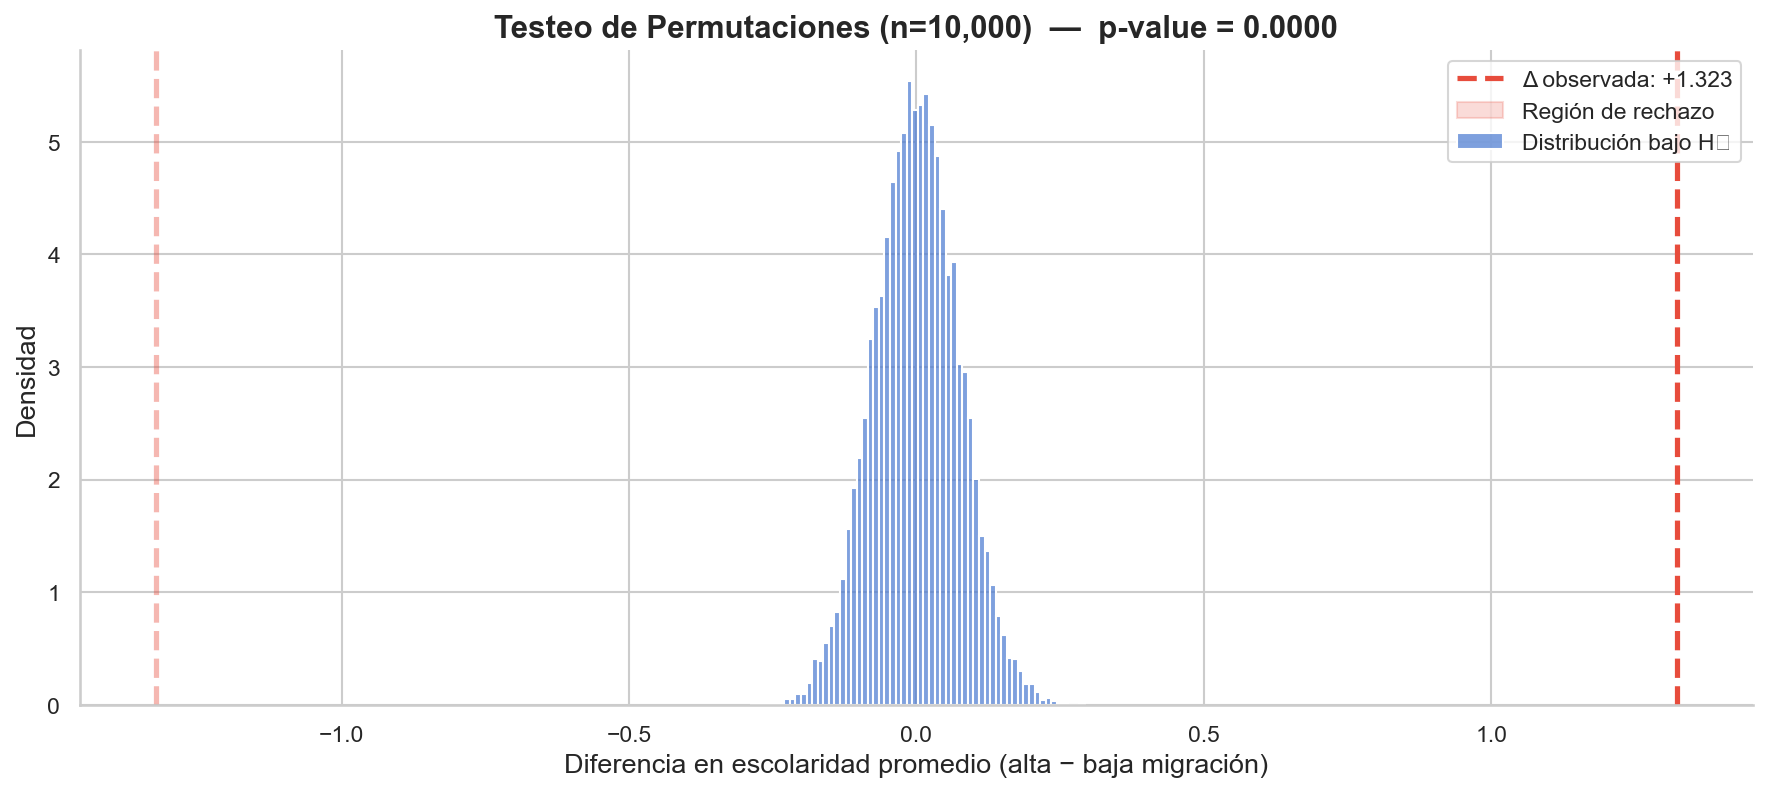


✅ p-value = 0.000000 < 0.05 → Rechazamos H₀
   La diferencia en escolaridad entre zonas de alta y baja migración ES significativa.


In [36]:
# Dividir zonas en alta/baja migración (mediana como umbral)
mediana_migr = indicadores['PCT_EXTRAN'].median()
grupo_alta = indicadores[indicadores['PCT_EXTRAN'] >= mediana_migr]['ESCOLARIDAD_PROM']
grupo_baja = indicadores[indicadores['PCT_EXTRAN'] < mediana_migr]['ESCOLARIDAD_PROM']

# Diferencia observada
diff_obs = grupo_alta.mean() - grupo_baja.mean()

print('┌─────────────────────────────────────────────────────┐')
print(f'│  Escolaridad prom. — Alta migración:  {grupo_alta.mean():>8.2f} años  │')
print(f'│  Escolaridad prom. — Baja migración:  {grupo_baja.mean():>8.2f} años  │')
print(f'│  Diferencia observada:                {diff_obs:>8.2f} años  │')
print('└─────────────────────────────────────────────────────┘')
print()

# Bootstrap de permutaciones
np.random.seed(42)
n_boot = 10_000
combined = pd.concat([grupo_alta, grupo_baja]).values
n_alta = len(grupo_alta)

diffs_perm = np.empty(n_boot)
for i in range(n_boot):
    perm = np.random.permutation(combined)
    diffs_perm[i] = perm[:n_alta].mean() - perm[n_alta:].mean()

p_value = np.mean(np.abs(diffs_perm) >= np.abs(diff_obs))

# Visualización
fig, ax = plt.subplots(figsize=(12, 5.5))
sns.histplot(diffs_perm, bins=60, color=C_PRIMARY, edgecolor='white', alpha=0.7,
             ax=ax, stat='density', label='Distribución bajo H₀')
ax.axvline(diff_obs, color=C_HIGHLIGHT, linewidth=2.5, linestyle='--',
           label=f'Δ observada: {diff_obs:+.3f}')
ax.axvline(-diff_obs, color=C_HIGHLIGHT, linewidth=2.5, linestyle='--', alpha=0.4)

# Shade rejection region
x_vals = np.linspace(diffs_perm.min(), diffs_perm.max(), 300)
from scipy.stats import gaussian_kde
kde = gaussian_kde(diffs_perm)
y_kde = kde(x_vals)
ax.fill_between(x_vals, y_kde, where=(np.abs(x_vals) >= np.abs(diff_obs)),
                color=C_HIGHLIGHT, alpha=0.2, label='Región de rechazo')

ax.set_xlabel('Diferencia en escolaridad promedio (alta − baja migración)')
ax.set_ylabel('Densidad')
ax.set_title(f'Testeo de Permutaciones (n={n_boot:,})  —  p-value = {p_value:.4f}')
ax.legend(frameon=True, facecolor='white', edgecolor='#ccc', fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig('fig_bootstrap_test.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

if p_value < 0.05:
    print(f'\n✅ p-value = {p_value:.6f} < 0.05 → Rechazamos H₀')
    print('   La diferencia en escolaridad entre zonas de alta y baja migración ES significativa.')
else:
    print(f'\n⚠️  p-value = {p_value:.6f} ≥ 0.05 → No podemos rechazar H₀')

## 8. Visualización Espacial

### 8.1 Mapa de vulnerabilidad y escolaridad por zona censal

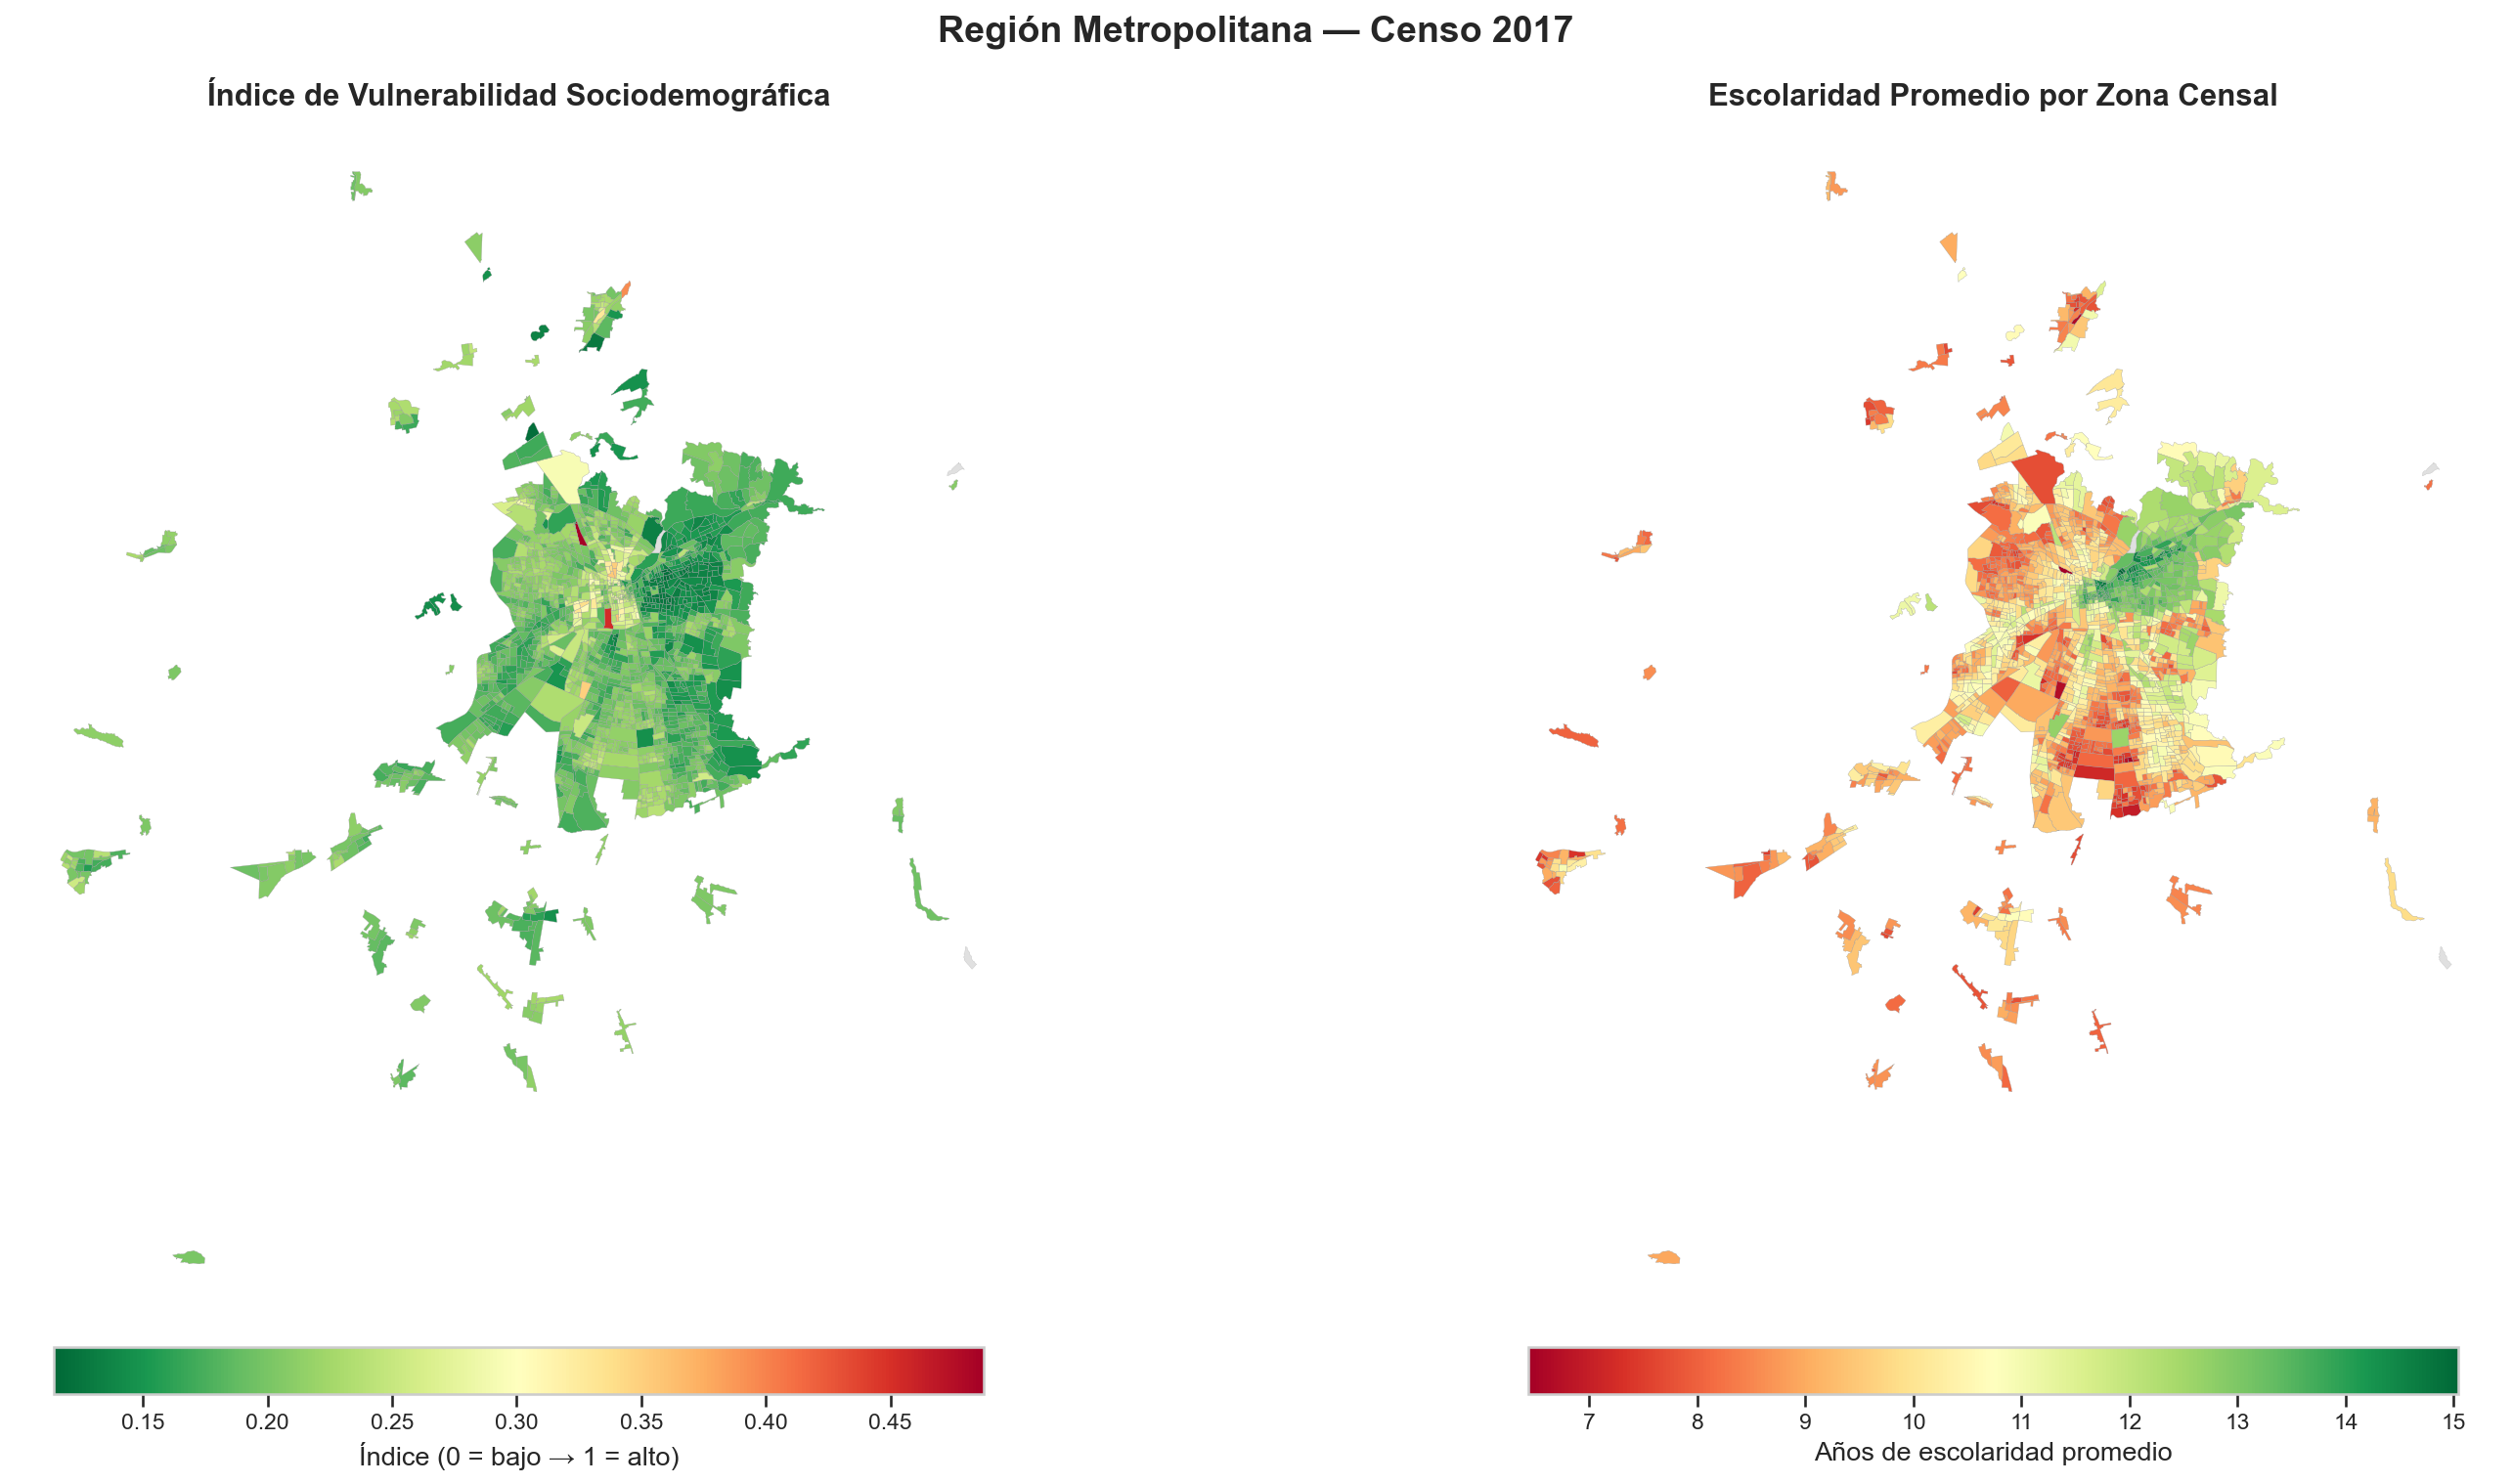

In [37]:
# Merge índice + escolaridad al GeoDataFrame
zonas_viz = zonas_censales.merge(
    ind_norm[['INDICE_VULNERABILIDAD']].reset_index(),
    on='ID_ZONA_U', how='left'
).merge(
    indicadores[['ESCOLARIDAD_PROM']].reset_index(),
    on='ID_ZONA_U', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(22, 11),
                         subplot_kw={'aspect': 'equal'})

# --- Mapa 1: Vulnerabilidad ---
zonas_viz.plot(
    ax=axes[0], column='INDICE_VULNERABILIDAD', cmap='RdYlGn_r',
    legend=True, missing_kwds={'color': '#e0e0e0', 'edgecolor': '#bbb', 'label': 'Sin datos'},
    edgecolor='#999', linewidth=0.15,
    legend_kwds={'label': 'Índice (0 = bajo → 1 = alto)', 'shrink': 0.55,
                 'orientation': 'horizontal', 'pad': 0.02}
)
axes[0].set_title('Índice de Vulnerabilidad Sociodemográfica', fontsize=15, fontweight='bold')
axes[0].set_axis_off()

# --- Mapa 2: Escolaridad ---
zonas_viz.plot(
    ax=axes[1], column='ESCOLARIDAD_PROM', cmap='RdYlGn',
    legend=True, missing_kwds={'color': '#e0e0e0', 'edgecolor': '#bbb', 'label': 'Sin datos'},
    edgecolor='#999', linewidth=0.15,
    legend_kwds={'label': 'Años de escolaridad promedio', 'shrink': 0.55,
                 'orientation': 'horizontal', 'pad': 0.02}
)
axes[1].set_title('Escolaridad Promedio por Zona Censal', fontsize=15, fontweight='bold')
axes[1].set_axis_off()

fig.suptitle('Región Metropolitana — Censo 2017', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(w_pad=2)
plt.savefig('fig_mapas_coropleticos.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 9. Conclusiones

1. **Índice de vulnerabilidad**: Se construyó un índice compuesto multivariable que identifica las zonas censales con mayor concentración de factores de riesgo sociodemográfico en la RM.

2. **Desigualdad educativa como predictor**: El análisis de correlación de Pearson revela cuál de los 5 componentes tiene la mayor asociación con el índice compuesto de vulnerabilidad.

3. **Testeo de hipótesis**: Mediante bootstrap de permutaciones, se evaluó si las zonas con alta proporción de migrantes presentan niveles de escolaridad significativamente diferentes, aportando evidencia estadística más allá de la mera observación descriptiva.

4. **Dimensión espacial**: Los mapas coropléticos permiten visualizar la co-localización de vulnerabilidad y baja escolaridad, evocando el análisis de **John Snow (1854)** discutido en Clase 1: la geografía revela patrones que los promedios ocultan.

### Métodos utilizados

| Método | Referencia en el curso |
|---|---|
| Histogramas, boxplots, estadísticas de resumen | Clase 2 — EDA |
| Correlación de Pearson (ρ) | Clase 2 — Estadísticas de resumen |
| Bootstrap de permutaciones | Clase 2 — Bootstrapping y testeo de hipótesis |
| Mapas coropléticos con GeoPandas | Clase 1 — Ciencia de Datos Geográfica |
| Normalización MinMaxScaler | Clase 1 — sklearn |